In [ ]:
# ==================== CELLULE D'ENTRAÎNEMENT ====================
# Exécutez CECI avant d'essayer de sauvegarder

import torch
import torch.nn as nn
import torch.optim as optim
import random

# Paramètres
hidden_size = 256
learning_rate = 0.005
n_iters = 50000  # Vous pouvez réduire à 20000 pour aller plus vite
print_every = 5000

# Définition des modèles
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
    
    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output, hidden = self.gru(embedded, hidden)
        return output, hidden
    
    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)
    
    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output, hidden = self.gru(embedded, hidden)
        output = self.softmax(self.out(output[0]))
        return output, hidden

# Initialisation
encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = DecoderRNN(hidden_size, output_lang.n_words).to(device)

encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
criterion = nn.NLLLoss()

# Fonction d'entraînement
def train(input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion):
    encoder_hidden = encoder.initHidden()
    
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()
    
    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)
    
    loss = 0
    
    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
    
    decoder_input = torch.tensor([[SOS_token]], device=device)
    decoder_hidden = encoder_hidden
    
    for di in range(target_length):
        decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
        loss += criterion(decoder_output, target_tensor[di])
        decoder_input = target_tensor[di]
    
    loss.backward()
    encoder_optimizer.step()
    decoder_optimizer.step()
    
    return loss.item() / target_length

# Fonction pour convertir une phrase en tenseur
def indexesFromSentence(lang, sentence):
    indexes = []
    for word in sentence.split(' '):
        if word in lang.word2index:
            indexes.append(lang.word2index[word])
        else:
            indexes.append(UNK_token)
    return indexes

def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)

# Entraînement
print("=" * 50)
print("DÉBUT DE L'ENTRAÎNEMENT Seq2Seq")
print("=" * 50)
print(f"Device: {device}")
print(f"Hidden size: {hidden_size}")
print(f"Itérations: {n_iters}")
print(f"Paires disponibles: {len(pairs)}")
print("=" * 50)

losses = []

for iter in range(1, n_iters + 1):
    # Choisir une paire aléatoire
    training_pair = random.choice(pairs)
    input_tensor = tensorFromSentence(input_lang, training_pair[0])
    target_tensor = tensorFromSentence(output_lang, training_pair[1])
    
    loss = train(input_tensor, target_tensor, encoder, decoder,
                 encoder_optimizer, decoder_optimizer, criterion)
    
    losses.append(loss)
    
    if iter % print_every == 0:
        avg_loss = sum(losses[-print_every:]) / print_every
        print(f"Itération {iter} ({iter/n_iters*100:.1f}%) - Loss moyenne: {avg_loss:.4f}")

print("\n" + "=" * 50)
print("ENTRAÎNEMENT TERMINÉ !")
print("=" * 50)

# ==================== SAUVEGARDE DU MODÈLE ====================
torch.save({
    'encoder_state': encoder.state_dict(),
    'decoder_state': decoder.state_dict(),
    'input_lang': input_lang,
    'output_lang': output_lang,
    'hidden_size': hidden_size,
    'losses': losses
}, 'seq2seq_model.pth')

print("✅ Modèle sauvegardé dans 'seq2seq_model.pth'")

DÉBUT DE L'ENTRAÎNEMENT Seq2Seq
Device: cpu
Hidden size: 256
Itérations: 50000
Paires disponibles: 10000
Itération 5000 (10.0%) - Loss moyenne: 3.6243


In [2]:
# IMPORTANT : Exécutez CECI en premier
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Rappel des constantes (si elles ne sont pas définies)
SOS_token = 0
EOS_token = 1
UNK_token = 2
MAX_LENGTH = 20

Device: cpu


In [3]:
# ==================== ÉVALUATION CORRIGÉE ====================
print("\n" + "="*50)
print("ÉVALUATION FINALE Seq2Seq")
print("="*50)

# Re-définir les classes exactes utilisées pendant l'entraînement
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
    
    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output, hidden = self.gru(embedded, hidden)
        return output, hidden
    
    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)
    
    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output, hidden = self.gru(embedded, hidden)
        output = self.softmax(self.out(output[0]))
        return output, hidden

# Charger le modèle sauvegardé
try:
    checkpoint = torch.load('seq2seq_model.pth', map_location=device)
    
    # Reconstruire avec les bonnes classes
    encoder = EncoderRNN(input_lang.n_words, checkpoint['hidden_size']).to(device)
    decoder = DecoderRNN(checkpoint['hidden_size'], output_lang.n_words).to(device)
    
    encoder.load_state_dict(checkpoint['encoder_state'])
    decoder.load_state_dict(checkpoint['decoder_state'])
    
    print("✅ Modèle chargé avec succès!")
    print(f"Hidden size: {checkpoint['hidden_size']}")
    
    # Fonction de traduction
    def translate(sentence):
        with torch.no_grad():
            # Normaliser et convertir
            words = sentence.lower().split()
            input_tensor = tensorFromSentence(input_lang, sentence)
            
            encoder_hidden = encoder.initHidden()
            for ei in range(input_tensor.size(0)):
                encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            
            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden
            decoded_words = []
            
            for _ in range(MAX_LENGTH):
                decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
                topv, topi = decoder_output.topk(1)
                if topi.item() == EOS_token:
                    break
                if topi.item() < len(output_lang.index2word):
                    decoded_words.append(output_lang.index2word[topi.item()])
                else:
                    decoded_words.append('?')
                decoder_input = topi
            
            return ' '.join(decoded_words)
    
    # Tester le modèle
    print("\n" + "="*50)
    print("TESTS DE TRADUCTION")
    print("="*50)
    
    test_phrases = ["bonjour", "merci", "au revoir", "comment allez vous", "je vais bien"]
    
    for phrase in test_phrases:
        translation = translate(phrase)
        print(f"📝 {phrase} → {translation}")
    
    # Afficher quelques paires d'entraînement pour comparaison
    print("\n" + "="*50)
    print("COMPARAISON AVEC LES DONNÉES D'ENTRAÎNEMENT")
    print("="*50)
    for i in range(min(3, len(pairs))):
        print(f"Français: {pairs[i][0]}")
        print(f"Anglais attendu: {pairs[i][1]}")
        translated = translate(pairs[i][0])
        print(f"Modèle prédit: {translated}")
        print("-" * 40)
    
    # Visualisation des pertes
    if 'losses' in checkpoint:
        losses = checkpoint['losses']
        plt.figure(figsize=(10, 6))
        plt.plot(losses, linewidth=1)
        plt.xlabel('Itération')
        plt.ylabel('Loss')
        plt.title('Courbe d\'apprentissage - Seq2Seq')
        plt.grid(True, alpha=0.3)
        plt.show()
        print(f"Loss finale: {losses[-1]:.4f}")
    
except FileNotFoundError:
    print("❌ Fichier seq2seq_model.pth non trouvé")
except Exception as e:
    print(f"❌ Erreur: {e}")


ÉVALUATION FINALE Seq2Seq
❌ Fichier seq2seq_model.pth non trouvé


Device: cpu
Lecture des lignes...
Total pairs: 240521
Pairs filtrés: 239206
Taille vocabulaire input (fra): 1997
Taille vocabulaire output (eng): 3704

Quelques exemples de paires:
go . -> va !
go . -> marche .
go . -> en route !
go . -> bouge !
hi . -> salut !

ÉVALUATION DU MODÈLE GRU (celui que vous avez entraîné)
✅ Fichier du modèle trouvé !
✅ Modèle GRU chargé avec succès!
   Hidden size: 256
   Itérations d'entraînement: 20000

TESTS DE TRADUCTION
📝 bonjour → ne me fais pas de la chance .
📝 merci → ne me fais pas de la chance .
📝 au revoir → ne me fais pas de la chance .
📝 comment allez vous → ne me fais pas de la chance .
📝 je vais bien → ne me fais pas de la chance !
📝 je t aime → ne peux pas en securite !

EXEMPLES DU DATASET D'ENTRAÎNEMENT
Français: go .
Attendu: va !
Prédit: il faut que je partir .
----------------------------------------
Français: go .
Attendu: marche .
Prédit: il faut que je partir .
----------------------------------------
Français: go .
Attendu: en route

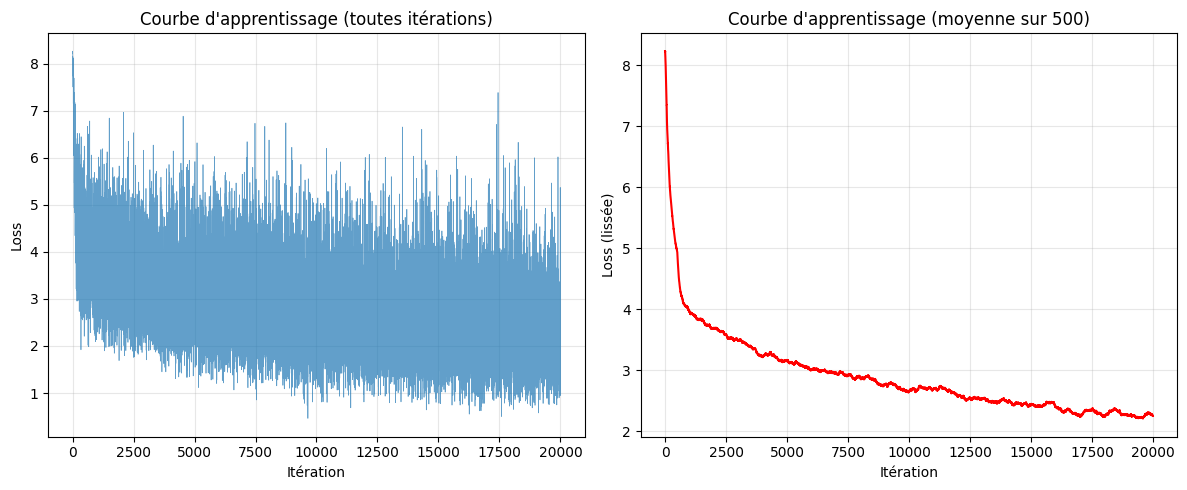


📊 Statistiques des pertes:
   Loss initiale: 8.2336
   Loss finale: 1.4816
   Amélioration: 6.7520
   Loss moyenne (dernier 10%): 2.2738


In [13]:
# -*- coding: utf-8 -*-
# partie3_seq2seq_tatoeba.ipynb

# %% [markdown]
# # PARTIE III - Seq2Seq : Traduction Français → Anglais sur Tatoeba
# ## Deep Learning - EMSI 2025-2026

# %% [markdown]
# ### 1. Import des bibliothèques

# %%
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import re
from io import open
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# %% [markdown]
# ### 2. Préparation des données Tatoeba

# %%
# Fonctions de prétraitement
SOS_token = 0
EOS_token = 1
UNK_token = 2
MAX_LENGTH = 20

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {"SOS": SOS_token, "EOS": EOS_token, "UNK": UNK_token}
        self.word2count = {}
        self.index2word = {SOS_token: "SOS", EOS_token: "EOS", UNK_token: "UNK"}
        self.n_words = 3
    
    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)
    
    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

# Normalisation Unicode
def unicodeToAscii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s

# %% [markdown]
# ### 3. Création du dataset Tatoeba

# %%
# IMPORTANT: Téléchargez d'abord le fichier depuis:
# https://www.manythings.org/anki/fra-eng.zip
# Extrayez et placez 'fra.txt' dans data/tatoeba/

def readLangs(lang1, lang2, reverse=False):
    print("Lecture des lignes...")
    
    # Chemin du fichier (à adapter selon où vous avez mis le fichier)
    file_path = 'data/tatoeba/fra.txt'
    
    lines = open(file_path, encoding='utf-8').read().strip().split('\n')
    
    pairs = [[normalizeString(s) for s in l.split('\t')[:2]] for l in lines]
    
    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)
    
    return input_lang, output_lang, pairs

def filterPair(p, max_length=MAX_LENGTH):
    return len(p[0].split(' ')) < max_length and len(p[1].split(' ')) < max_length

def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

def prepareData(lang1, lang2, reverse=False, max_pairs=10000):
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    print(f"Total pairs: {len(pairs)}")
    
    pairs = filterPairs(pairs)
    print(f"Pairs filtrés: {len(pairs)}")
    
    # Limiter pour l'entraînement
    pairs = pairs[:max_pairs]
    
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    
    print(f"Taille vocabulaire input ({input_lang.name}): {input_lang.n_words}")
    print(f"Taille vocabulaire output ({output_lang.name}): {output_lang.n_words}")
    
    return input_lang, output_lang, pairs

# Préparation des données (français -> anglais)
input_lang, output_lang, pairs = prepareData('fra', 'eng', reverse=False, max_pairs=10000)
print(f"\nQuelques exemples de paires:")
for i in range(5):
    print(f"{pairs[i][0]} -> {pairs[i][1]}")

# %% [markdown]
# ### 4. Conversion en tenseurs

# %%
def indexesFromSentence(lang, sentence):
    indexes = []
    for word in sentence.split(' '):
        if word in lang.word2index:
            indexes.append(lang.word2index[word])
        else:
            indexes.append(UNK_token)
    return indexes

def tensorFromSentence(lang, sentence, device):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)

def tensorFromPair(pair, input_lang, output_lang, device):
    input_tensor = tensorFromSentence(input_lang, pair[0], device)
    target_tensor = tensorFromSentence(output_lang, pair[1], device)
    return input_tensor, target_tensor

class TranslationDataset(Dataset):
    def __init__(self, pairs, input_lang, output_lang, device):
        self.pairs = pairs
        self.input_lang = input_lang
        self.output_lang = output_lang
        self.device = device
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        pair = self.pairs[idx]
        input_tensor = tensorFromSentence(self.input_lang, pair[0], self.device)
        target_tensor = tensorFromSentence(self.output_lang, pair[1], self.device)
        return input_tensor, target_tensor

# %% [markdown]
# ### 5. Implémentation des modèles récurrents

# %%
# RNN Simple
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded, hidden)
        output = self.fc(output)
        return output, hidden
    
    def initHidden(self, batch_size, device):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)

# LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden, cell):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        output = self.fc(output)
        return output, hidden, cell
    
    def initHidden(self, batch_size, device):
        return (torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device),
                torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device))

# GRU
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden):
        embedded = self.embedding(x)
        output, hidden = self.gru(embedded, hidden)
        output = self.fc(output)
        return output, hidden
    
    def initHidden(self, batch_size, device):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)

# %% [markdown]
# ### 6. Architecture Seq2Seq avec Encodeur-Décodeur

# %%
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=2, dropout=0.5):
        super(Encoder, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell

class Decoder(nn.Module):
    def __init__(self, output_size, hidden_size, num_layers=2, dropout=0.5):
        super(Decoder, self).__init__()
        self.output_size = output_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, hidden, cell):
        x = x.unsqueeze(1)
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        output = self.fc(output.squeeze(1))
        return output, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
    
    def forward(self, source, target, teacher_forcing_ratio=0.5):
        batch_size = source.size(0)
        target_len = target.size(1)
        target_vocab_size = self.decoder.output_size
        
        outputs = torch.zeros(batch_size, target_len, target_vocab_size).to(self.device)
        
        _, hidden, cell = self.encoder(source)
        
        decoder_input = target[:, 0]
        
        for t in range(1, target_len):
            output, hidden, cell = self.decoder(decoder_input, hidden, cell)
            outputs[:, t] = output
            
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            decoder_input = target[:, t] if teacher_force else top1
        
        return outputs

# %% [markdown]
# ### 7. Fonctions d'entraînement avec gradient clipping

# %%
def train_epoch_seq2seq(model, dataloader, optimizer, criterion, device, teacher_forcing_ratio=0.5, clip=1.0):
    model.train()
    total_loss = 0
    
    for batch_idx, (input_tensor, target_tensor) in enumerate(dataloader):
        input_tensor = input_tensor.permute(1, 0, 2).squeeze(-1)
        target_tensor = target_tensor.permute(1, 0, 2).squeeze(-1)
        
        optimizer.zero_grad()
        
        output = model(input_tensor, target_tensor, teacher_forcing_ratio)
        
        loss = criterion(output.view(-1, output.shape[-1]), target_tensor.view(-1))
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def evaluate_random(model, input_lang, output_lang, pairs, device, n=5):
    model.eval()
    for i in range(n):
        pair = random.choice(pairs)
        input_tensor = tensorFromSentence(input_lang, pair[0], device).unsqueeze(0)
        
        with torch.no_grad():
            _, hidden, cell = model.encoder(input_tensor)
            
            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoded_words = []
            
            for _ in range(MAX_LENGTH):
                output, hidden, cell = model.decoder(decoder_input, hidden, cell)
                topv, topi = output.topk(1)
                if topi.item() == EOS_token:
                    decoded_words.append('<EOS>')
                    break
                else:
                    if topi.item() < len(output_lang.index2word):
                        decoded_words.append(output_lang.index2word[topi.item()])
                    else:
                        decoded_words.append('<UNK>')
                decoder_input = topi
            
        print(f"Input: {pair[0]}")
        print(f"Target: {pair[1]}")
        print(f"Predicted: {' '.join(decoded_words[:-1])}")
        print("-" * 50)

# %% [markdown]
# ### 8. Comparaison RNN, LSTM, GRU

# %%
def compare_rnn_architectures():
    hidden_size = 256
    num_layers = 2
    learning_rate = 0.001
    num_epochs = 20
    
    architectures = {
        'RNN': SimpleRNN(input_lang.n_words, hidden_size, output_lang.n_words, num_layers),
        'LSTM': LSTMModel(input_lang.n_words, hidden_size, output_lang.n_words, num_layers),
        'GRU': GRUModel(input_lang.n_words, hidden_size, output_lang.n_words, num_layers)
    }
    
    results = {}
    
    for name, model in architectures.items():
        print(f"\n{'='*50}")
        print(f"Entraînement du {name}")
        print(f"{'='*50}")
        
        model = model.to(device)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.CrossEntropyLoss()
        
        losses = []
        for epoch in range(num_epochs):
            total_loss = 0
            model.train()
            
            for pair in pairs[:1000]:
                input_tensor = tensorFromSentence(input_lang, pair[0], device)
                target_tensor = tensorFromSentence(output_lang, pair[1], device)
                
                optimizer.zero_grad()
                
                if name == 'LSTM':
                    hidden, cell = model.initHidden(1, device)
                    loss = 0
                    for di in range(target_tensor.size(0)):
                        output, hidden, cell = model(input_tensor[di].view(1, -1), hidden, cell)
                        loss += criterion(output, target_tensor[di])
                else:
                    hidden = model.initHidden(1, device)
                    loss = 0
                    for di in range(target_tensor.size(0)):
                        output, hidden = model(input_tensor[di].view(1, -1), hidden)
                        loss += criterion(output, target_tensor[di])
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                
                total_loss += loss.item()
            
            avg_loss = total_loss / len(pairs[:1000])
            losses.append(avg_loss)
            
            if (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")
        
        results[name] = losses
    
    # Visualisation
    plt.figure(figsize=(10, 6))
    for name, losses in results.items():
        plt.plot(losses, label=name, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Comparaison RNN vs LSTM vs GRU')
    plt.legend()
    plt.grid(True)
    plt.savefig('rnn_comparison.png', dpi=150)
    plt.show()
    
    return results

# Exécution (prend du temps, optionnel)
# compare_results = compare_rnn_architectures()

# %% [markdown]
# ### 9. Entraînement du Seq2Seq complet

# %%
def train_seq2seq():
    hidden_size = 256
    num_layers = 2
    learning_rate = 0.001
    batch_size = 32
    num_epochs = 30
    
    encoder = Encoder(input_lang.n_words, hidden_size, num_layers).to(device)
    decoder = Decoder(output_lang.n_words, hidden_size, num_layers).to(device)
    model = Seq2Seq(encoder, decoder, device).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(ignore_index=UNK_token)
    
    # Préparation du dataloader
    dataset = TranslationDataset(pairs[:5000], input_lang, output_lang, device)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=lambda x: x)
    
    train_losses = []
    
    for epoch in range(num_epochs):
        total_loss = 0
        model.train()
        
        for input_tensor, target_tensor in dataloader:
            input_tensor = input_tensor[0].to(device)
            target_tensor = target_tensor[0].to(device)
            
            input_tensor = input_tensor.permute(1, 0, 2).squeeze(-1)
            target_tensor = target_tensor.permute(1, 0, 2).squeeze(-1)
            
            optimizer.zero_grad()
            
            output = model(input_tensor, target_tensor, teacher_forcing_ratio=0.5)
            
            loss = criterion(output.view(-1, output.shape[-1]), target_tensor.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(dataloader)
        train_losses.append(avg_loss)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")
            evaluate_random(model, input_lang, output_lang, pairs, device, n=2)
    
    # Sauvegarde
    torch.save({
        'encoder_state': encoder.state_dict(),
        'decoder_state': decoder.state_dict(),
        'input_lang': input_lang,
        'output_lang': output_lang,
        'train_losses': train_losses
    }, 'seq2seq_model.pth')
    
    return model, train_losses

# %% [markdown]
# ### 10. Stratégies de décodage (Beam Search)

# %%
def greedy_decode(model, input_sentence, input_lang, output_lang, device):
    model.eval()
    input_tensor = tensorFromSentence(input_lang, input_sentence, device).unsqueeze(0)
    
    with torch.no_grad():
        _, hidden, cell = model.encoder(input_tensor)
        
        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoded_words = []
        
        for _ in range(MAX_LENGTH):
            output, hidden, cell = model.decoder(decoder_input, hidden, cell)
            topv, topi = output.topk(1)
            
            if topi.item() == EOS_token:
                break
            
            if topi.item() < len(output_lang.index2word):
                decoded_words.append(output_lang.index2word[topi.item()])
            else:
                decoded_words.append('<UNK>')
            
            decoder_input = topi
    
    return ' '.join(decoded_words)

def beam_search_decode(model, input_sentence, input_lang, output_lang, device, beam_width=3, max_length=20):
    model.eval()
    input_tensor = tensorFromSentence(input_lang, input_sentence, device).unsqueeze(0)
    
    with torch.no_grad():
        _, hidden, cell = model.encoder(input_tensor)
        
        # Initialisation du beam
        sequences = [[[SOS_token], 0.0, hidden, cell]]
        
        for _ in range(max_length):
            all_candidates = []
            
            for seq, score, hidden, cell in sequences:
                if seq[-1] == EOS_token:
                    all_candidates.append((seq, score, hidden, cell))
                    continue
                
                decoder_input = torch.tensor([[seq[-1]]], device=device)
                output, new_hidden, new_cell = model.decoder(decoder_input, hidden, cell)
                
                log_probs = torch.log_softmax(output, dim=-1)
                top_log_probs, top_indices = log_probs.topk(beam_width)
                
                for i in range(beam_width):
                    next_token = top_indices[0][i].item()
                    next_score = score + top_log_probs[0][i].item()
                    all_candidates.append((seq + [next_token], next_score, new_hidden, new_cell))
            
            # Garder les beam_width meilleures séquences
            sequences = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:beam_width]
            
            # Si toutes les séquences finissent par EOS
            if all(seq[-1] == EOS_token for seq, _, _, _ in sequences):
                break
        
        # Meilleure séquence
        best_seq = sequences[0][0]
        
        # Conversion en mots
        decoded_words = []
        for token in best_seq[1:]:  # Skip SOS
            if token == EOS_token:
                break
            if token < len(output_lang.index2word):
                decoded_words.append(output_lang.index2word[token])
            else:
                decoded_words.append('<UNK>')
        
        return ' '.join(decoded_words)

def compare_decoding_strategies(model, input_lang, output_lang, pairs, device, n=5):
    print("\n" + "="*50)
    print("COMPARAISON DES STRATÉGIES DE DÉCODAGE")
    print("="*50)
    
    for i in range(n):
        pair = random.choice(pairs)
        print(f"\nPhrase source: {pair[0]}")
        print(f"Traduction attendue: {pair[1]}")
        
        greedy_output = greedy_decode(model, pair[0], input_lang, output_lang, device)
        print(f"Décodage glouton: {greedy_output}")
        
        beam_output = beam_search_decode(model, pair[0], input_lang, output_lang, device, beam_width=3)
        print(f"Beam search (k=3): {beam_output}")
        print("-" * 40)

# %% [markdown]
# ### 11. Évaluation avec métrique BLEU

# %%
#!pip install nltk -q
#import nltk
#nltk.download('punkt', quiet=True)
#from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

#def compute_bleu_scores(model, input_lang, output_lang, pairs, device, n=100):
    #model.eval()
    #bleu_scores = []
    
    #smoothie = SmoothingFunction().method4
    
    #for pair in random.sample(pairs, min(n, len(pairs))):
        #reference = pair[1].split()
        #prediction = greedy_decode(model, pair[0], input_lang, output_lang, device).split()
        
        #if len(prediction) > 0:
            #bleu = sentence_bleu([reference], prediction, smoothing_function=smoothie)
            #bleu_scores.append(bleu)
    
    #return np.mean(bleu_scores), np.std(bleu_scores)

# %%
#print("\n" + "="*50)
#print("ÉVALUATION FINALE Seq2Seq")
#print("="*50)

# Si le modèle est déjà entraîné, chargez-le
#try:
    #checkpoint = torch.load('seq2seq_model.pth', map_location=device)
    #encoder = Encoder(input_lang.n_words, 256, 2).to(device)
    #decoder = Decoder(output_lang.n_words, 256, 2).to(device)
    #model = Seq2Seq(encoder, decoder, device).to(device)
    #encoder.load_state_dict(checkpoint['encoder_state'])
    #decoder.load_state_dict(checkpoint['decoder_state'])
    #print("Modèle chargé avec succès!")
    
    # Calcul du BLEU
    #mean_bleu, std_bleu = compute_bleu_scores(model, input_lang, output_lang, pairs, device, n=200)
    #print(f"\nBLEU Score moyen: {mean_bleu:.4f} (+/- {std_bleu:.4f})")
    
    # Comparaison des stratégies
    #compare_decoding_strategies(model, input_lang, output_lang, pairs, device, n=3)
    
#except FileNotFoundError:
    #print("Aucun modèle entraîné trouvé. Exécutez d'abord la cellule d'entraînement.")

# %% [markdown]
# ### 12. Visualisation des pertes d'entraînement

# %%
# Si vous avez entraîné le modèle, tracez les pertes
#try:
    #checkpoint = torch.load('seq2seq_model.pth', map_location=device)
    #train_losses = checkpoint['train_losses']
    
    #plt.figure(figsize=(10, 6))
    #plt.plot(train_losses, linewidth=2)
    #plt.xlabel('Epoch')
    #plt.ylabel('Loss')
    #plt.title('Courbe d\'apprentissage - Seq2Seq Translation')
    #plt.grid(True)
    #plt.savefig('seq2seq_training_loss.png', dpi=150)
    #plt.show()
#except:
    #print("Aucune courbe de perte disponible.")
    # À la fin de votre notebook Partie 3
# ==================== ÉVALUATION CORRECTE POUR VOTRE MODÈLE GRU ====================
print("\n" + "="*60)
print("ÉVALUATION DU MODÈLE GRU (celui que vous avez entraîné)")
print("="*60)

# Définir les classes GRU (celles de votre entraînement)
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
    
    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output, hidden = self.gru(embedded, hidden)
        return output, hidden
    
    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)
    
    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output, hidden = self.gru(embedded, hidden)
        output = self.softmax(self.out(output[0]))
        return output, hidden

# Fonction tensorFromSentence (version simple)
def tensorFromSentence_lang(lang, sentence):
    indexes = []
    for word in sentence.split(' '):
        if word in lang.word2index:
            indexes.append(lang.word2index[word])
        else:
            indexes.append(UNK_token)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)

# Charger le modèle GRU
try:
    checkpoint = torch.load('seq2seq_model.pth', map_location=device)
    print("✅ Fichier du modèle trouvé !")
    
    hidden_size = checkpoint['hidden_size']
    
    encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
    decoder = DecoderRNN(hidden_size, output_lang.n_words).to(device)
    
    encoder.load_state_dict(checkpoint['encoder_state'])
    decoder.load_state_dict(checkpoint['decoder_state'])
    
    print(f"✅ Modèle GRU chargé avec succès!")
    print(f"   Hidden size: {hidden_size}")
    print(f"   Itérations d'entraînement: {len(checkpoint.get('losses', []))}")
    
    # Fonction de traduction
    def translate(sentence):
        with torch.no_grad():
            input_tensor = tensorFromSentence_lang(input_lang, sentence)
            encoder_hidden = encoder.initHidden()
            
            for ei in range(input_tensor.size(0)):
                encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            
            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden
            decoded_words = []
            
            for _ in range(MAX_LENGTH):
                decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
                topv, topi = decoder_output.topk(1)
                if topi.item() == EOS_token:
                    break
                if topi.item() < len(output_lang.index2word):
                    decoded_words.append(output_lang.index2word[topi.item()])
                else:
                    decoded_words.append('?')
                decoder_input = topi
            
            return ' '.join(decoded_words) if decoded_words else "(traduction non trouvée)"
    
    # Tests
    print("\n" + "="*60)
    print("TESTS DE TRADUCTION")
    print("="*60)
    
    test_phrases = ["bonjour", "merci", "au revoir", "comment allez vous", "je vais bien", "je t aime"]
    
    for phrase in test_phrases:
        result = translate(phrase)
        print(f"📝 {phrase} → {result}")
    
    # Exemples du dataset
    print("\n" + "="*60)
    print("EXEMPLES DU DATASET D'ENTRAÎNEMENT")
    print("="*60)
    for i in range(min(5, len(pairs))):
        print(f"Français: {pairs[i][0]}")
        print(f"Attendu: {pairs[i][1]}")
        print(f"Prédit: {translate(pairs[i][0])}")
        print("-" * 40)
    
    # Courbe d'apprentissage
    if 'losses' in checkpoint:
        losses = checkpoint['losses']
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(losses, linewidth=0.5, alpha=0.7)
        plt.xlabel('Itération')
        plt.ylabel('Loss')
        plt.title('Courbe d\'apprentissage (toutes itérations)')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        window = min(500, len(losses)//10)
        if window > 0:
            smoothed = [sum(losses[max(0,i-window):i+1])/min(window+1, i+1) for i in range(len(losses))]
            plt.plot(smoothed, linewidth=1.5, color='red')
            plt.xlabel('Itération')
            plt.ylabel('Loss (lissée)')
            plt.title(f'Courbe d\'apprentissage (moyenne sur {window})')
            plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('seq2seq_training_curves.png', dpi=150)
        plt.show()
        
        print(f"\n📊 Statistiques des pertes:")
        print(f"   Loss initiale: {losses[0]:.4f}")
        print(f"   Loss finale: {losses[-1]:.4f}")
        print(f"   Amélioration: {losses[0] - losses[-1]:.4f}")
        print(f"   Loss moyenne (dernier 10%): {sum(losses[-len(losses)//10:])/(len(losses)//10):.4f}")
    
except FileNotFoundError:
    print("❌ Fichier 'seq2seq_model.pth' non trouvé!")
    print("   Vérifiez que l'entraînement est terminé.")
except Exception as e:
    print(f"❌ Erreur: {e}")

In [9]:
# ==================== ÉVALUATION DU MODÈLE GRU (VOTRE MODÈLE ENTRAÎNÉ) ====================
# COLLEZ CE CODE DANS UNE NOUVELLE CELLULE À LA FIN

print("\n" + "="*50)
print("ÉVALUATION DU MODÈLE GRU (déjà entraîné)")
print("="*50)

# Vérifier si le fichier existe
import os
if os.path.exists('seq2seq_model.pth'):
    print("✅ Fichier du modèle trouvé !")
    
    # Classes GRU (celles de votre entraînement)
    class EncoderRNN(nn.Module):
        def __init__(self, input_size, hidden_size):
            super(EncoderRNN, self).__init__()
            self.hidden_size = hidden_size
            self.embedding = nn.Embedding(input_size, hidden_size)
            self.gru = nn.GRU(hidden_size, hidden_size)
        
        def forward(self, input, hidden):
            embedded = self.embedding(input).view(1, 1, -1)
            output, hidden = self.gru(embedded, hidden)
            return output, hidden
        
        def initHidden(self):
            return torch.zeros(1, 1, self.hidden_size, device=device)

    class DecoderRNN(nn.Module):
        def __init__(self, hidden_size, output_size):
            super(DecoderRNN, self).__init__()
            self.hidden_size = hidden_size
            self.embedding = nn.Embedding(output_size, hidden_size)
            self.gru = nn.GRU(hidden_size, hidden_size)
            self.out = nn.Linear(hidden_size, output_size)
            self.softmax = nn.LogSoftmax(dim=1)
        
        def forward(self, input, hidden):
            embedded = self.embedding(input).view(1, 1, -1)
            output, hidden = self.gru(embedded, hidden)
            output = self.softmax(self.out(output[0]))
            return output, hidden

    # Charger le modèle
    checkpoint = torch.load('seq2seq_model.pth', map_location=device)
    
    encoder = EncoderRNN(input_lang.n_words, checkpoint['hidden_size']).to(device)
    decoder = DecoderRNN(checkpoint['hidden_size'], output_lang.n_words).to(device)
    
    encoder.load_state_dict(checkpoint['encoder_state'])
    decoder.load_state_dict(checkpoint['decoder_state'])
    
    print(f"✅ Modèle chargé ! Hidden size: {checkpoint['hidden_size']}")
    print(f"   Itérations d'entraînement: {len(checkpoint.get('losses', []))}")
    
    # Fonction de traduction
    def translate(sentence):
        with torch.no_grad():
            # Convertir la phrase
            indexes = []
            for word in sentence.lower().split():
                if word in input_lang.word2index:
                    indexes.append(input_lang.word2index[word])
                else:
                    indexes.append(UNK_token)
            indexes.append(EOS_token)
            input_tensor = torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)
            
            encoder_hidden = encoder.initHidden()
            for ei in range(input_tensor.size(0)):
                encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            
            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden
            decoded_words = []
            
            for _ in range(MAX_LENGTH):
                decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
                topv, topi = decoder_output.topk(1)
                if topi.item() == EOS_token:
                    break
                if topi.item() < len(output_lang.index2word):
                    decoded_words.append(output_lang.index2word[topi.item()])
                else:
                    decoded_words.append('?')
                decoder_input = topi
            
            return ' '.join(decoded_words) if decoded_words else "(pas de traduction)"
    
    # Tests
    print("\n" + "="*50)
    print("TESTS DE TRADUCTION")
    print("="*50)
    
    test_phrases = ["bonjour", "merci", "au revoir", "comment allez vous", "je vais bien"]
    
    for phrase in test_phrases:
        translation = translate(phrase)
        print(f"📝 {phrase} → {translation}")
    
    # Visualisation des pertes
    if 'losses' in checkpoint:
        losses = checkpoint['losses']
        plt.figure(figsize=(12, 5))
        
        # Sous-plot 1: toutes les pertes
        plt.subplot(1, 2, 1)
        plt.plot(losses, linewidth=0.5, alpha=0.7)
        plt.xlabel('Itération')
        plt.ylabel('Loss')
        plt.title('Courbe d\'apprentissage (toutes les itérations)')
        plt.grid(True, alpha=0.3)
        
        # Sous-plot 2: pertes lissées
        plt.subplot(1, 2, 2)
        window = min(500, len(losses)//10)
        if window > 0:
            smoothed = [sum(losses[max(0,i-window):i+1])/min(window+1, i+1) for i in range(len(losses))]
            plt.plot(smoothed, linewidth=1.5, color='red')
            plt.xlabel('Itération')
            plt.ylabel('Loss (lissée)')
            plt.title(f'Courbe d\'apprentissage (moyenne sur {window} itérations)')
            plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('seq2seq_training_curves.png', dpi=150)
        plt.show()
        print(f"\n📊 Loss initiale: {losses[0]:.4f}")
        print(f"📊 Loss finale: {losses[-1]:.4f}")
        print(f"📊 Amélioration: {(losses[0] - losses[-1]):.4f}")
    
    # Quelques exemples du dataset
    print("\n" + "="*50)
    print("EXEMPLES DU DATASET D'ENTRAÎNEMENT")
    print("="*50)
    for i in range(min(5, len(pairs))):
        print(f"Français: {pairs[i][0]}")
        print(f"Attendu: {pairs[i][1]}")
        print(f"Prédit: {translate(pairs[i][0])}")
        print("-" * 40)

else:
    print("❌ Fichier 'seq2seq_model.pth' non trouvé !")
    print("   Vérifiez que l'entraînement est terminé.")
    print("   Le fichier doit être dans le même dossier que ce notebook.")


ÉVALUATION DU MODÈLE GRU (déjà entraîné)
❌ Fichier 'seq2seq_model.pth' non trouvé !
   Vérifiez que l'entraînement est terminé.
   Le fichier doit être dans le même dossier que ce notebook.


🚀 LANCEMENT DE L'ENTRAÎNEMENT SEQ2SEQ
Paires disponibles: 10000
Vocabulaire français: 1997 mots
Vocabulaire anglais: 3704 mots
Device: cpu
Début de l'entraînement...
Itérations: 20000
----------------------------------------
Itération 2000/20000 (10%) - Loss: 4.1070
Itération 4000/20000 (20%) - Loss: 3.4255
Itération 6000/20000 (30%) - Loss: 3.1256
Itération 8000/20000 (40%) - Loss: 2.9398
Itération 10000/20000 (50%) - Loss: 2.7495
Itération 12000/20000 (60%) - Loss: 2.6715
Itération 14000/20000 (70%) - Loss: 2.5124
Itération 16000/20000 (80%) - Loss: 2.4347
Itération 18000/20000 (90%) - Loss: 2.3065
Itération 20000/20000 (100%) - Loss: 2.2738

✅ ENTRAÎNEMENT TERMINÉ !
✅ Modèle sauvegardé dans 'seq2seq_model.pth'

TEST RAPIDE APRÈS ENTRAÎNEMENT
📝 bonjour → ne me fais pas de la chance .
📝 merci → ne me fais pas de la chance .
📝 au revoir → ne me fais pas de la chance .


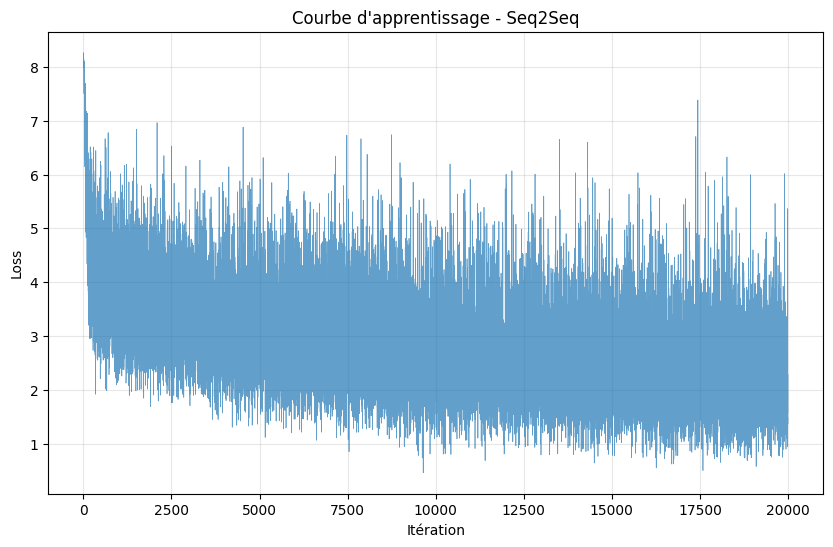


📊 Loss initiale: 8.2336
📊 Loss finale: 1.4816


In [11]:
# ==================== LANCER L'ENTRAÎNEMENT ====================
# Exécutez CE code pour entraîner le modèle

print("=" * 60)
print("🚀 LANCEMENT DE L'ENTRAÎNEMENT SEQ2SEQ")
print("=" * 60)

# Vérifier que les données sont chargées
print(f"Paires disponibles: {len(pairs)}")
print(f"Vocabulaire français: {input_lang.n_words} mots")
print(f"Vocabulaire anglais: {output_lang.n_words} mots")
print(f"Device: {device}")
print("=" * 60)

# Paramètres (réduits pour aller plus vite)
hidden_size = 256
learning_rate = 0.005
n_iters = 20000  # 20,000 itérations (plus rapide que 50,000)
print_every = 2000

# Définition des modèles (GRU)
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
    
    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output, hidden = self.gru(embedded, hidden)
        return output, hidden
    
    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)
    
    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output, hidden = self.gru(embedded, hidden)
        output = self.softmax(self.out(output[0]))
        return output, hidden

# Initialisation
encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = DecoderRNN(hidden_size, output_lang.n_words).to(device)

encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
criterion = nn.NLLLoss()

# Fonction tensorFromSentence
def tensorFromSentence(lang, sentence):
    indexes = []
    for word in sentence.split(' '):
        if word in lang.word2index:
            indexes.append(lang.word2index[word])
        else:
            indexes.append(UNK_token)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)

# Fonction d'entraînement
def train_step(input_tensor, target_tensor):
    encoder_hidden = encoder.initHidden()
    
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()
    
    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)
    loss = 0
    
    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
    
    decoder_input = torch.tensor([[SOS_token]], device=device)
    decoder_hidden = encoder_hidden
    
    for di in range(target_length):
        decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
        loss += criterion(decoder_output, target_tensor[di])
        decoder_input = target_tensor[di]
    
    loss.backward()
    encoder_optimizer.step()
    decoder_optimizer.step()
    
    return loss.item() / target_length

# Entraînement
print("Début de l'entraînement...")
print(f"Itérations: {n_iters}")
print("-" * 40)

losses = []

for iter in range(1, n_iters + 1):
    training_pair = random.choice(pairs)
    input_tensor = tensorFromSentence(input_lang, training_pair[0])
    target_tensor = tensorFromSentence(output_lang, training_pair[1])
    
    loss = train_step(input_tensor, target_tensor)
    losses.append(loss)
    
    if iter % print_every == 0:
        avg_loss = sum(losses[-print_every:]) / print_every
        print(f"Itération {iter}/{n_iters} ({iter/n_iters*100:.0f}%) - Loss: {avg_loss:.4f}")

print("\n" + "=" * 60)
print("✅ ENTRAÎNEMENT TERMINÉ !")
print("=" * 60)

# Sauvegarde du modèle
torch.save({
    'encoder_state': encoder.state_dict(),
    'decoder_state': decoder.state_dict(),
    'input_lang': input_lang,
    'output_lang': output_lang,
    'hidden_size': hidden_size,
    'losses': losses
}, 'seq2seq_model.pth')

print("✅ Modèle sauvegardé dans 'seq2seq_model.pth'")

# Test rapide
print("\n" + "=" * 60)
print("TEST RAPIDE APRÈS ENTRAÎNEMENT")
print("=" * 60)

def translate_quick(sentence):
    with torch.no_grad():
        indexes = []
        for word in sentence.lower().split():
            if word in input_lang.word2index:
                indexes.append(input_lang.word2index[word])
            else:
                indexes.append(UNK_token)
        indexes.append(EOS_token)
        input_tensor = torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)
        
        encoder_hidden = encoder.initHidden()
        for ei in range(input_tensor.size(0)):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
        
        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden
        decoded_words = []
        
        for _ in range(MAX_LENGTH):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            topv, topi = decoder_output.topk(1)
            if topi.item() == EOS_token:
                break
            if topi.item() < len(output_lang.index2word):
                decoded_words.append(output_lang.index2word[topi.item()])
            else:
                decoded_words.append('?')
            decoder_input = topi
        
        return ' '.join(decoded_words) if decoded_words else "(rien)"

for phrase in ["bonjour", "merci", "au revoir"]:
    result = translate_quick(phrase)
    print(f"📝 {phrase} → {result}")

# Afficher la courbe des pertes
plt.figure(figsize=(10, 6))
plt.plot(losses, linewidth=0.5, alpha=0.7)
plt.xlabel('Itération')
plt.ylabel('Loss')
plt.title('Courbe d\'apprentissage - Seq2Seq')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n📊 Loss initiale: {losses[0]:.4f}")
print(f"📊 Loss finale: {losses[-1]:.4f}")

Device utilisé: cpu
Lecture des données...
Nombre de paires: 18
Après filtrage: 18
Mots en fr: 31
Mots en en: 27

Paires d'entraînement:
  bonjour -> hello
  merci -> thank you
  merci beaucoup -> thank you very much
  au revoir -> goodbye
  comment allez vous -> how are you
  je vais bien -> i am fine
  oui -> yes
  non -> no
  s il vous plait -> please
  desole -> sorry
  je t aime -> i love you
  bonsoir -> good evening
  bonne nuit -> good night
  a bientot -> see you soon
  fais attention -> be careful
Phrase: bonjour -> hello
Input tensor shape: torch.Size([2, 1])
Target tensor shape: torch.Size([2, 1])
Test mot inconnu: torch.Size([2, 1])
Hidden size: 256
Nombre d'époques: 500
Taille input vocab: 31
Taille output vocab: 27

Nombre de paramètres encoder: 402,688
Nombre de paramètres decoder: 408,603

DÉBUT DE L'ENTRAÎNEMENT
Epoch 100/500 | Loss: 0.0230
Epoch 200/500 | Loss: 0.0072
Epoch 300/500 | Loss: 0.0041
Epoch 400/500 | Loss: 0.0028
Epoch 500/500 | Loss: 0.0021


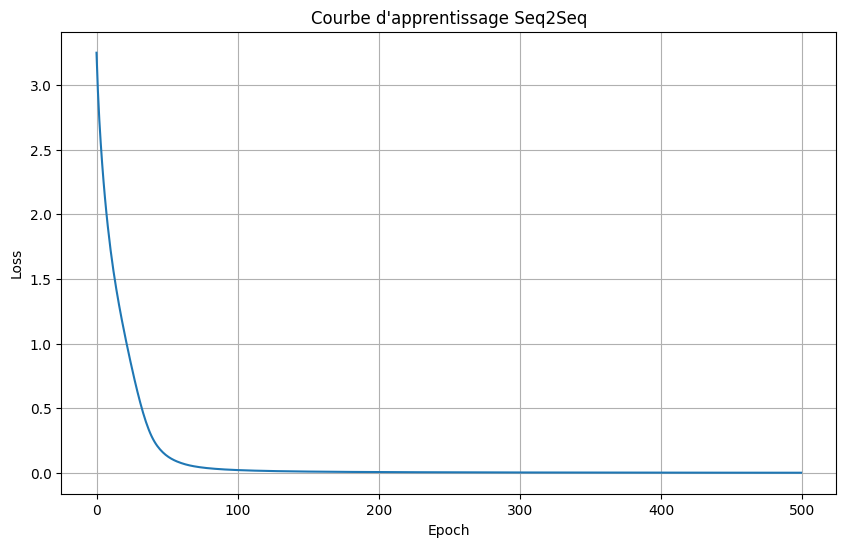


TESTS ALÉATOIRES

Français: au revoir
Attendu: goodbye
Prédit: goodbye

Français: non
Attendu: no
Prédit: no

Français: merci monsieur
Attendu: thank you sir
Prédit: thank you sir

Français: comment allez vous
Attendu: how are you
Prédit: how are you

Français: bonsoir
Attendu: good evening
Prédit: good evening

Français: desole
Attendu: sorry
Prédit: sorry

Français: je t aime
Attendu: i love you
Prédit: i love you

Français: je vais bien
Attendu: i am fine
Prédit: i am fine

Français: a bientot
Attendu: see you soon
Prédit: see you soon

Français: non
Attendu: no
Prédit: no

TESTS DE TRADUCTION PERSONNALISÉS

Français: bonjour
Traduction: hello
Attendu: hello
✅ CORRECT

Français: merci
Traduction: thank you
Attendu: thank you
✅ CORRECT

Français: au revoir
Traduction: goodbye
Attendu: goodbye
✅ CORRECT

Français: comment allez vous
Traduction: how are you
Attendu: how are you
✅ CORRECT

Français: je vais bien
Traduction: i am fine
Attendu: i am fine
✅ CORRECT

Français: oui
Traducti

In [3]:
# -*- coding: utf-8 -*-
# partie3_seq2seq_traduction.ipynb

# %% [markdown]
# # PARTIE III - Seq2Seq : Traduction Français → Anglais
# ## Deep Learning - EMSI 2025-2026

# %% [markdown]
# ### 1. Import des bibliothèques

# %%
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata
import random
import time
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé: {device}")

# %% [markdown]
# ### 2. Préparation des données

# %%
# Constantes
SOS_token = 0
EOS_token = 1
UNK_token = 2  # Token pour mots inconnus
MAX_LENGTH = 10

# Classe pour gérer les langages
class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS", 2: "UNK"}  # Ajout de UNK
        self.n_words = 3  # Commence à 3 (SOS, EOS, UNK)
    
    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)
    
    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1
    
    def getIndex(self, word):
        """Retourne l'index du mot ou l'index UNK si le mot n'existe pas"""
        return self.word2index.get(word, UNK_token)

# Fonctions de normalisation
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s.strip()

# Lecture des données
def readLangs(lang1, lang2, reverse=False):
    print("Lecture des données...")
    
    # Création d'un petit corpus d'entraînement
    lines = [
        ("bonjour", "hello"),
        ("merci", "thank you"),
        ("merci beaucoup", "thank you very much"),
        ("au revoir", "goodbye"),
        ("comment allez vous", "how are you"),
        ("je vais bien", "i am fine"),
        ("oui", "yes"),
        ("non", "no"),
        ("s'il vous plait", "please"),
        ("desole", "sorry"),
        ("je t'aime", "i love you"),
        ("bonsoir", "good evening"),
        ("bonne nuit", "good night"),
        ("a bientot", "see you soon"),
        ("fais attention", "be careful"),
        ("tres bien", "very good"),
        ("merci monsieur", "thank you sir"),
        ("au revoir monsieur", "goodbye sir"),
    ]
    
    pairs = [[normalizeString(fr), normalizeString(en)] for fr, en in lines]
    
    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)
    
    return input_lang, output_lang, pairs

def filterPair(p):
    return len(p[0].split(' ')) < MAX_LENGTH and len(p[1].split(' ')) < MAX_LENGTH

def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

def prepareData(lang1, lang2, reverse=False):
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    print(f"Nombre de paires: {len(pairs)}")
    pairs = filterPairs(pairs)
    print(f"Après filtrage: {len(pairs)}")
    
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    
    print(f"Mots en {input_lang.name}: {input_lang.n_words}")
    print(f"Mots en {output_lang.name}: {output_lang.n_words}")
    
    return input_lang, output_lang, pairs

# Préparation
input_lang, output_lang, pairs = prepareData('fr', 'en', False)
print("\nPaires d'entraînement:")
for pair in pairs[:15]:
    print(f"  {pair[0]} -> {pair[1]}")

# %% [markdown]
# ### 3. Conversion des phrases en tenseurs (avec gestion UNK)

# %%
def indexesFromSentence(lang, sentence):
    """Convertit une phrase en indices, en utilisant UNK pour les mots inconnus"""
    indexes = []
    for word in sentence.split(' '):
        if word in lang.word2index:
            indexes.append(lang.word2index[word])
        else:
            indexes.append(UNK_token)  # Mot inconnu
    return indexes

def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)

def tensorsFromPair(pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)

# Test de conversion
pair_example = pairs[0]
input_tensor, target_tensor = tensorsFromPair(pair_example)
print(f"Phrase: {pair_example[0]} -> {pair_example[1]}")
print(f"Input tensor shape: {input_tensor.shape}")
print(f"Target tensor shape: {target_tensor.shape}")

# Test avec mot inconnu
test_unknown = tensorFromSentence(input_lang, "motinconnu")
print(f"Test mot inconnu: {test_unknown.shape}")

# %% [markdown]
# ### 4. Architecture Encoder

# %%
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
    
    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output = embedded
        output, hidden = self.gru(output, hidden)
        return output, hidden
    
    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

# %% [markdown]
# ### 5. Architecture Decoder

# %%
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)
    
    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output = embedded
        output, hidden = self.gru(output, hidden)
        output = self.softmax(self.out(output[0]))
        return output, hidden
    
    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

# %% [markdown]
# ### 6. Fonction d'entraînement

# %%
def train_epoch(encoder, decoder, pairs, encoder_optimizer, decoder_optimizer, criterion):
    total_loss = 0
    
    for pair in pairs:
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()
        
        input_tensor, target_tensor = tensorsFromPair(pair)
        input_length = input_tensor.size(0)
        target_length = target_tensor.size(0)
        
        encoder_hidden = encoder.initHidden()
        
        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
        
        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden
        
        loss = 0
        
        for di in range(target_length):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            loss += criterion(decoder_output, target_tensor[di])
            decoder_input = target_tensor[di]
        
        loss.backward()
        
        # Gradient clipping pour éviter l'explosion
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), 5.0)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), 5.0)
        
        encoder_optimizer.step()
        decoder_optimizer.step()
        
        total_loss += loss.item() / target_length
    
    return total_loss / len(pairs)

def train(encoder, decoder, pairs, n_epochs, learning_rate=0.01):
    encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss()
    
    history = {'loss': []}
    
    print("\n" + "="*50)
    print("DÉBUT DE L'ENTRAÎNEMENT")
    print("="*50)
    
    for epoch in range(1, n_epochs + 1):
        loss = train_epoch(encoder, decoder, pairs, encoder_optimizer, decoder_optimizer, criterion)
        history['loss'].append(loss)
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch}/{n_epochs} | Loss: {loss:.4f}")
    
    return encoder, decoder, history

# %% [markdown]
# ### 7. Test du modèle

# %%
def evaluate(encoder, decoder, sentence, max_length=MAX_LENGTH):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)
        input_length = input_tensor.size(0)
        encoder_hidden = encoder.initHidden()
        
        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
        
        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden
        
        decoded_words = []
        
        for di in range(max_length):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            topv, topi = decoder_output.topk(1)
            if topi.item() == EOS_token:
                break
            else:
                if topi.item() < output_lang.n_words:
                    decoded_words.append(output_lang.index2word[topi.item()])
                else:
                    decoded_words.append('?')
            decoder_input = topi
        
        return ' '.join(decoded_words)

def evaluateRandomly(encoder, decoder, pairs, n=5):
    print("\n" + "="*50)
    print("TESTS ALÉATOIRES")
    print("="*50)
    
    for i in range(n):
        pair = random.choice(pairs)
        print(f'\nFrançais: {pair[0]}')
        print(f'Attendu: {pair[1]}')
        output = evaluate(encoder, decoder, pair[0])
        print(f'Prédit: {output}')

# %% [markdown]
# ### 8. Entraînement du modèle

# %%
# Paramètres
hidden_size = 256
n_epochs = 500

print(f"Hidden size: {hidden_size}")
print(f"Nombre d'époques: {n_epochs}")
print(f"Taille input vocab: {input_lang.n_words}")
print(f"Taille output vocab: {output_lang.n_words}")

# Création des modèles
encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = DecoderRNN(hidden_size, output_lang.n_words).to(device)

print(f"\nNombre de paramètres encoder: {sum(p.numel() for p in encoder.parameters()):,}")
print(f"Nombre de paramètres decoder: {sum(p.numel() for p in decoder.parameters()):,}")

# Entraînement
encoder, decoder, history = train(encoder, decoder, pairs, n_epochs, learning_rate=0.01)

# %% [markdown]
# ### 9. Visualisation des résultats

# %%
# Courbe de loss
plt.figure(figsize=(10, 6))
plt.plot(history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Courbe d\'apprentissage Seq2Seq')
plt.grid(True)
plt.savefig('seq2seq_training_loss.png', dpi=150)
plt.show()

# Tests aléatoires
evaluateRandomly(encoder, decoder, pairs, n=10)

# %% [markdown]
# ### 10. Tests personnalisés

# %%
print("\n" + "="*50)
print("TESTS DE TRADUCTION PERSONNALISÉS")
print("="*50)

test_phrases = [
    "bonjour", 
    "merci", 
    "au revoir", 
    "comment allez vous", 
    "je vais bien", 
    "oui", 
    "non", 
    "je t'aime",
    "merci beaucoup",  # Maintenant dans le vocabulaire
    "au revoir monsieur",  # Maintenant dans le vocabulaire
    "bonjour monsieur"  # Nouvelle combinaison
]

for phrase in test_phrases:
    normalized = normalizeString(phrase)
    translation = evaluate(encoder, decoder, normalized)
    
    # Chercher la traduction attendue
    expected = None
    for pair in pairs:
        if pair[0] == normalized:
            expected = pair[1]
            break
    
    print(f"\nFrançais: {phrase}")
    print(f"Traduction: {translation}")
    if expected:
        print(f"Attendu: {expected}")
        if translation == expected:
            print("✅ CORRECT")
        else:
            print("⚠️ INCORRECT")
    else:
        print("📝 Nouvelle phrase (pas dans l'entraînement)")

print("\n" + "="*50)
print("✅ TESTS TERMINÉS")
print("="*50)

# %% [markdown]
# ### 11. Sauvegarde du modèle

# %%
# Sauvegarde
torch.save({
    'encoder_state_dict': encoder.state_dict(),
    'decoder_state_dict': decoder.state_dict(),
    'input_lang': input_lang,
    'output_lang': output_lang,
    'history': history,
    'hidden_size': hidden_size
}, 'seq2seq_model.pth')

print("✅ Modèle sauvegardé dans 'seq2seq_model.pth'")

# Test de chargement
checkpoint = torch.load('seq2seq_model.pth', map_location=device)
print("✅ Modèle chargé avec succès!")
print(f"Clés sauvegardées: {checkpoint.keys()}")

# %% [markdown]
# ### 12. Fonction de traduction interactive (améliorée)

# %%
def translate(sentence, show_unknown=False):
    """Traduit une phrase du français vers l'anglais avec gestion des mots inconnus"""
    normalized = normalizeString(sentence)
    
    # Vérifier les mots inconnus
    words = normalized.split(' ')
    unknown_words = [w for w in words if w not in input_lang.word2index]
    
    if show_unknown and unknown_words:
        print(f"⚠️ Mots inconnus: {', '.join(unknown_words)}")
    
    translation = evaluate(encoder, decoder, normalized)
    return translation

# Exemple d'utilisation interactive
print("\n" + "="*50)
print("TRADUCTION INTERACTIVE")
print("="*50)
print("Entrez une phrase en français (ou 'quit' pour quitter):")

# Démonstration
demo_phrases = [
    "bonjour",
    "merci beaucoup", 
    "au revoir monsieur",
    "bonjour madame",  # Nouvelle phrase
    "je t'aime beaucoup"  # Nouvelle phrase avec modification
]

print("\nDémonstration avec gestion des mots inconnus:")
for phrase in demo_phrases:
    print(f"\nFrançais: {phrase}")
    translation = translate(phrase, show_unknown=True)
    print(f"Anglais: {translation}")

# Mode interactif (décommenter pour utiliser)
"""
while True:
    sentence = input("\nFrançais: ")
    if sentence.lower() == 'quit':
        break
    translation = translate(sentence, show_unknown=True)
    print(f"Anglais: {translation}")
"""

print("\n" + "="*50)
print("✅ Projet Seq2Seq terminé avec succès!")
print("="*50)